In [2]:
# ===== 1. Import Libraries yang Digunakan =====

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pywt
import glob
from scipy.signal import butter, filtfilt
from scipy.stats import zscore
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

In [3]:
# ===== Konfigurasi Parameter =====

fs = 250
windowsize = 2500
normal = 0
afib = 1

In [4]:
# ===== 2. Import Data (Satu Data yang Sama untuk Training & Testing) =====

datapath     = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/dataekglabel_nano_berhasil.csv"
project_path = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/"
DATA_DIR     = project_path + "Data Wearable EKG-Nano (Berhasil)"
model_path   = os.path.join(project_path, "catnet_primer_smote.h5")
logdir       = os.path.join(project_path, "logs_catnet_primer_smote")

# Load label CSV (buang label -2 / Tidak Terdeteksi)
labels_df = pd.read_csv(datapath)
labels_df = labels_df[labels_df['label'].isin([0, 1])].reset_index(drop=True)

# Load semua file sinyal EKG
file_cache = {}
for csv_path in glob.glob(os.path.join(DATA_DIR, "*.csv")):
    fname = os.path.basename(csv_path)
    df_tmp = pd.read_csv(csv_path)
    ekg = pd.to_numeric(df_tmp.iloc[:, 2], errors='coerce').dropna().values
    file_cache[fname] = ekg

print(f"Total label data  : {len(labels_df)} window")
print(f"  Normal: {sum(labels_df['label']==0)}, AFib: {sum(labels_df['label']==1)}")
print(f"File sinyal loaded: {len(file_cache)} file")

Total label data  : 823 window
  Normal: 699, AFib: 124
File sinyal loaded: 15 file


In [5]:
# ===== 3. Filtering dan Denoising Seluruh Data =====

# Bandpass Filter (data sudah 250 Hz, tanpa resample)
def apply_bandpass_filter(sig, fs=fs, lowcut=0.5, highcut=40.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, sig)

# Wavelet Denoising db5
def wavelet_denoise(signal_data, wavelet='db5', level=5):
    coeffs = pywt.wavedec(signal_data, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal_data)))
    denoised_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        denoised_coeffs.append(pywt.threshold(c, threshold, mode='soft'))
    reconstructed = pywt.waverec(denoised_coeffs, wavelet)
    return reconstructed[:len(signal_data)]

# Pipeline preprocessing (250 Hz langsung, tanpa resample)
def preprocess_window(window_signal):
    sig_bpf = apply_bandpass_filter(window_signal, fs=fs)
    sig_dwt = wavelet_denoise(sig_bpf)
    sig_norm = zscore(sig_dwt)
    return sig_norm

# Proses seluruh data
X_all = []
y_all = []
window_ids_all = []

print("[INFO] Memulai preprocessing seluruh data...")
for _, row in labels_df.iterrows():
    fname = row['filename']
    w_num = int(row['window_num'])
    label = int(row['label'])
    
    if fname not in file_cache:
        continue
    
    ekg = file_cache[fname]
    start = (w_num - 1) * windowsize
    end = start + windowsize
    
    if end > len(ekg):
        continue
    
    segment = ekg[start:end]
    processed = preprocess_window(segment)
    
    X_all.append(processed)
    y_all.append(label)
    window_ids_all.append(row['window_id'])

X_all = np.array(X_all)
y_all = np.array(y_all)
window_ids_all = np.array(window_ids_all)

print(f"[INFO] Preprocessing selesai: {len(X_all)} window")
print(f"  Normal: {sum(y_all==0)}, AFib: {sum(y_all==1)}")

[INFO] Memulai preprocessing seluruh data...
[INFO] Preprocessing selesai: 823 window
  Normal: 699, AFib: 124


In [6]:
# ===== 4. Pembagian Data: 70% Training, 15% Validasi, 15% Testing =====
# Split SEBELUM augmentasi agar data testing & validasi tetap data asli (tanpa data leakage)

# Langkah 1: Training (70%) vs Sisa (30%)
X_train_raw, X_temp, y_train_raw, y_temp, wid_train, wid_temp = train_test_split(X_all, y_all, window_ids_all,test_size=0.30,random_state=42,stratify=y_all)

# Langkah 2: Sisa (30%) → Validasi (15%) dan Testing (15%)
X_val, X_test, y_val, y_test, wid_val, wid_test = train_test_split(X_temp, y_temp, wid_temp,test_size=0.50,random_state=42,stratify=y_temp)

# Reshape Validation & Testing ke 3D: (n_samples, 2500, 1)
X_val  = X_val.reshape(-1, windowsize, 1)
X_test = X_test.reshape(-1, windowsize, 1)

print(f"{'='*60}")
print(f"  DISTRIBUSI DATA SPLIT (70/15/15) — DATA ASLI SAJA")
print(f"{'='*60}")
print(f"  Training  : {len(X_train_raw):>5} window  (Normal: {sum(y_train_raw==0)}, AFib: {sum(y_train_raw==1)})")
print(f"  Validation: {len(X_val):>5} window  (Normal: {sum(y_val==0)}, AFib: {sum(y_val==1)})  ← data asli")
print(f"  Testing   : {len(X_test):>5} window  (Normal: {sum(y_test==0)}, AFib: {sum(y_test==1)})  ← data asli")
print(f"{'='*60}")
print(f"  Total     : {len(X_train_raw)+len(X_val)+len(X_test):>5} window")

  DISTRIBUSI DATA SPLIT (70/15/15) — DATA ASLI SAJA
  Training  :   576 window  (Normal: 489, AFib: 87)
  Validation:   123 window  (Normal: 105, AFib: 18)  ← data asli
  Testing   :   124 window  (Normal: 105, AFib: 19)  ← data asli
  Total     :   823 window


In [7]:
# ===== 5. Augmentasi & SMOTE-Tomek (HANYA Data Training) =====
# Validation & Testing TIDAK disentuh — tetap data asli

# --- 5a. Augmentasi Sinyal ---
def augment_signal(signal):
    augmented = []
    # 1. Jittering
    noise = np.random.normal(0, 0.05, len(signal))
    augmented.append(signal + noise)
    # 2. Scaling
    scale = np.random.uniform(0.9, 1.1)
    augmented.append(signal * scale)
    # 3. Time shifting
    shift = np.random.randint(-50, 50)
    augmented.append(np.roll(signal, shift))
    return augmented

X_augmented = list(X_train_raw)
y_augmented = list(y_train_raw)

for i in range(len(X_train_raw)):
    aug_signals = augment_signal(X_train_raw[i])
    for aug_sig in aug_signals:
        X_augmented.append(aug_sig)
        y_augmented.append(y_train_raw[i])

X_aug = np.array(X_augmented)
y_aug = np.array(y_augmented)

print(f"Training sebelum Augmentasi : {len(X_train_raw)} window")
print(f"Training sesudah Augmentasi : {len(X_aug)} window (x4)")
print(f"  Normal: {sum(y_aug==0)}, AFib: {sum(y_aug==1)}")

# --- 5b. SMOTE-Tomek Balancing ---
print(f"\n[INFO] Menjalankan SMOTE-Tomek pada Data Training...")
X_aug_2d = X_aug.reshape(X_aug.shape[0], -1)

smote_tomek = SMOTETomek(
    smote=SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42),
    random_state=42
)
X_balanced_2d, y_balanced = smote_tomek.fit_resample(X_aug_2d, y_aug)

# Reshape ke 3D: (n_samples, 2500, 1)
x_train = X_balanced_2d.reshape(-1, windowsize, 1)
y_train = y_balanced

# Shuffle data training final
acak = np.arange(x_train.shape[0])
np.random.shuffle(acak)
x_train = x_train[acak]
y_train = y_train[acak]

print(f"\nData Training Final (Augmented + SMOTE-Tomek + Shuffled):")
print(f"  Normal: {sum(y_train==0)}, AFib: {sum(y_train==1)}")
print(f"  Total : {len(y_train)} window")
print(f"  Shape : {x_train.shape}")

print(f"\n⚠️  Validation ({len(X_val)} window) & Testing ({len(X_test)} window) = DATA ASLI, tidak diaugmentasi")

Training sebelum Augmentasi : 576 window
Training sesudah Augmentasi : 2304 window (x4)
  Normal: 1956, AFib: 348

[INFO] Menjalankan SMOTE-Tomek pada Data Training...

Data Training Final (Augmented + SMOTE-Tomek + Shuffled):
  Normal: 1956, AFib: 1956
  Total : 3912 window
  Shape : (3912, 2500, 1)

⚠️  Validation (123 window) & Testing (124 window) = DATA ASLI, tidak diaugmentasi


In [8]:
# ===== Layer Attention untuk Model CAT-NET =====

# 1. Channel Attention Layer
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs): 
        super(ChannelAttention, self).__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio

    def build(self, input_shape):
        self.shared_layer_one = tf.keras.layers.Dense(self.filters // self.ratio, activation='relu', kernel_initializer='he_normal')
        self.shared_layer_two = tf.keras.layers.Dense(self.filters, kernel_initializer='he_normal')

    def call(self, inputs):
        avg_pool = tf.keras.layers.GlobalAveragePooling1D()(inputs)
        avg_pool = self.shared_layer_one(avg_pool)
        avg_pool = self.shared_layer_two(avg_pool)
        max_pool = tf.keras.layers.GlobalMaxPooling1D()(inputs)
        max_pool = self.shared_layer_one(max_pool)
        max_pool = self.shared_layer_two(max_pool)
        attention = tf.keras.layers.Add()([avg_pool, max_pool])
        attention = tf.keras.layers.Activation('sigmoid')(attention)
        attention = tf.keras.layers.Reshape((1, self.filters))(attention)
        return tf.keras.layers.Multiply()([inputs, attention])
    
# 2. Temporal/Spatial Attention Layer
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv1d = tf.keras.layers.Conv1D(filters=1, kernel_size=self.kernel_size, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)
    
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=2, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=2, keepdims=True)
        attention = tf.concat([avg_pool, max_pool], axis=2)
        attention = self.conv1d(attention)
        return inputs * attention

In [9]:
# ===== Layer Transformer Encoder untuk Model CAT-NET =====

class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dff, dropout_rate, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.multi_head_attention = tf.keras.layers.MultiHeadAttention(key_dim=d_model, num_heads=num_heads)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dense1 = tf.keras.layers.Dense(dff, activation='relu')
        self.dense2 = tf.keras.layers.Dense(d_model)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs, training=True):
        attn_output = self.multi_head_attention(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layer_norm1(inputs + attn_output)
        ffn_output = self.dense1(out1)
        ffn_output = self.dense2(ffn_output)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layer_norm2(out1 + ffn_output)

In [10]:
# ===== Fungsi untuk Positional Encoding pada Model CAT-NET =====

def positional_encoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return tf.constant(P, dtype=tf.float32)

In [11]:
# ===== Fungsi untuk Membangun Arsitektur Model CAT-NET =====

def buildModel():
    inputs = tf.keras.Input(shape=(windowsize, 1))

    # CNN Block 1
    x = tf.keras.layers.Conv1D(16, 21, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(16, 8)(x)
    x = SpatialAttention(7)(x)
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # CNN Block 2
    x = tf.keras.layers.Conv1D(32, 23, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(32, 8)(x)
    x = SpatialAttention(7)(x)
    x = tf.keras.layers.MaxPool1D(3, strides=2, padding='same')(x)

    # CNN Block 3
    x = tf.keras.layers.Conv1D(64, 25, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = ChannelAttention(64, 8)(x)
    x = SpatialAttention(7)(x)
    x = tf.keras.layers.AvgPool1D(3, strides=2, padding='same')(x)

    # CNN Block 4
    x = tf.keras.layers.Conv1D(128, 27, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    # Positional Encoding sebelum masuk ke Transformer
    pos_enc = positional_encoding(seq_len=x.shape[1], d=x.shape[2])
    x = x + pos_enc

    # Transformer Encoder Block
    x = TransformerEncoder(num_heads=4, d_model=128, dff=256, dropout_rate=0.1)(x)

    # Meratakan dimensi keluaran Transformer
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Dense Classifier
    x = tf.keras.layers.Dropout(rate=0.4)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs)

In [14]:
# ===== 7. Proses Training =====

if os.path.exists(model_path):
    print(f"[INFO] Ditemukan model yang sudah dilatih di: {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
            'TransformerEncoder': TransformerEncoder
        }
    )
else:
    print("[INFO] Model belum ada. Memulai proses Training...")
    model = buildModel()
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=project_path + "catnet_primer_smote.weights.h5",
        save_weights_only=True, monitor='val_accuracy', mode='max', save_best_only=True
    )
    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    )
    early_stop_cb = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
    )
    
    history = model.fit(
        x_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[tensorboard_callback, checkpoint_cb, reduce_lr_cb]
    )
    model.save(model_path)
    print(f"[INFO] Training Selesai! Model disimpan di: {model_path}")

[INFO] Model belum ada. Memulai proses Training...
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 103s 789ms/step - accuracy: 0.8960 - loss: 0.2736 - val_accuracy: 0.1463 - val_loss: 1.6728 - learning_rate: 0.0010
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 88s 714ms/step - accuracy: 0.9425 - loss: 0.1609 - val_accuracy: 0.1707 - val_loss: 3.8797 - learning_rate: 0.0010
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 87s 707ms/step - accuracy: 0.9594 - loss: 0.1218 - val_accuracy: 0.9350 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 100s 797ms/step - accuracy: 0.9765 - loss: 0.0756 - val_accuracy: 0.8862 - val_loss: 0.2796 - learning_rate: 0.0010
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 95s 770ms/step - accuracy: 0.9813 - loss: 0.0520 - val_accuracy: 0.9106 - val_loss: 0.5208 - learning_rate: 0.0010
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 106s 864ms/step - accuracy: 0.9849 - loss: 0.0403 - val_accuracy: 0.9106 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 7/10

[INFO] Training Selesai! Model disimpan di: /Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/catnet_primer_smote.h5


In [15]:
# ===== Tampilkan Ringkasan Arsitektur Model =====

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2500, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 2500, 16)       │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2500, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_6             │ (None, 2500, 16)       │            82 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_6             │ (None, 2500, 16)       │            14 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1250, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 1250, 32)       │        11,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1250, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_7             │ (None, 1250, 32)       │           292 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_7             │ (None, 1250, 32)       │            14 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 625, 64)        │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_8             │ (None, 625, 64)        │         1,096 │
│ (ChannelAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_8             │ (None, 625, 64)        │            14 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 313, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 313, 128)       │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 313, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_17 (Add)                    │ (None, 313, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,901,696 (7.25 MB)

 Trainable params: 633,738 (2.42 MB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 1,267,478 (4.84 MB)

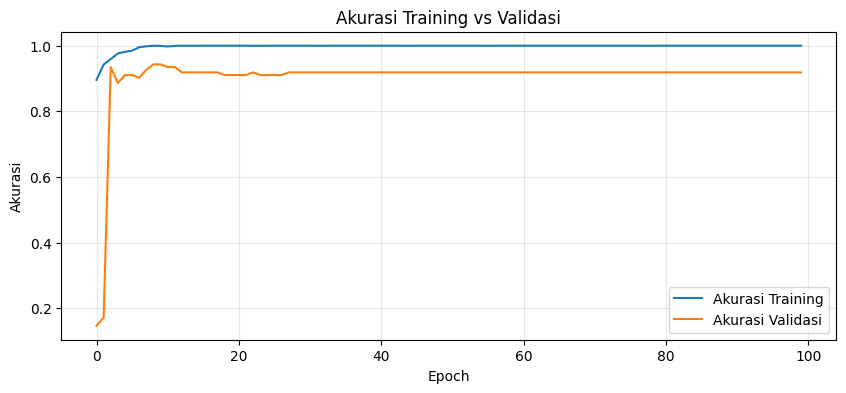

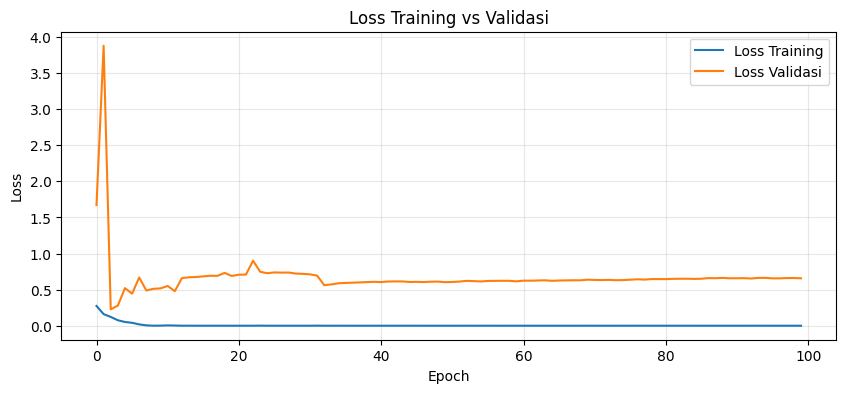

In [16]:
# ===== Plot Kurva Accuracy dan Loss dari Training =====

# 1. Akurasi
plt.figure(figsize=(10, 4))
plt.title('Akurasi Training vs Validasi')
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Loss
plt.figure(figsize=(10, 4))
plt.title('Loss Training vs Validasi')
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# ===== 8. Proses Testing (Data Asli — Tanpa Augmentasi) =====

print(f"X_test shape: {X_test.shape}")
print(f"y_test      : {len(y_test)} (Normal: {sum(y_test==0)}, AFib: {sum(y_test==1)})")

prediksi_prob = model.predict(X_test)
prediksi_kelas = np.argmax(prediksi_prob, axis=1)

label_map = {0: 'Normal', 1: 'AFib'}

print(f"\n{'Window':<30} {'Aktual':<10} {'Prediksi':<10} {'Confidence':<12} {'Hasil'}")
print("-" * 75)
for i in range(len(prediksi_kelas)):
    actual = label_map[y_test[i]]
    pred = label_map[prediksi_kelas[i]]
    conf = prediksi_prob[i][prediksi_kelas[i]] * 100
    status = '✅' if y_test[i] == prediksi_kelas[i] else '❌'
    print(f"{wid_test[i]:<30} {actual:<10} {pred:<10} {conf:.1f}%{'':>5} {status}")

n_afib = np.sum(prediksi_kelas == 1)
n_normal = np.sum(prediksi_kelas == 0)
print(f"\nTotal: {n_normal} Normal, {n_afib} AFib dari {len(prediksi_kelas)} window")

X_test shape: (124, 2500, 1)
y_test      : 124 (Normal: 105, AFib: 19)
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step

Window                         Aktual     Prediksi   Confidence   Hasil
---------------------------------------------------------------------------
Wearable EKG-Nano15.csv|w9     AFib       AFib       100.0%      ✅
Wearable EKG-Nano15.csv|w34    Normal     Normal     100.0%      ✅
Wearable EKG-Nano14.csv|w44    Normal     Normal     100.0%      ✅
Wearable EKG-Nano8.csv|w11     Normal     Normal     100.0%      ✅
Wearable EKG-Nano7.csv|w9      Normal     Normal     100.0%      ✅
Wearable EKG-Nano12.csv|w48    Normal     Normal     100.0%      ✅
Wearable EKG-Nano9.csv|w43     Normal     Normal     100.0%      ✅
Wearable EKG-Nano7.csv|w45     Normal     Normal     100.0%      ✅
Wearable EKG-Nano5.csv|w49     Normal     Normal     100.0%      ✅
Wearable EKG-Nano12.csv|w16    Normal     Normal     100.0%      ✅
Wearable EKG-Nano9.csv|w37     Normal     Normal     100.0%      ✅
Wear

In [18]:
# ===== 9. Hasil Performa Sistem =====

import seaborn as sns

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print('Training Accuracy   : %.2f%%' % (train_acc * 100))
print('Training Loss       : %.4f' % train_loss)
print('Validation Accuracy : %.2f%%' % (val_acc * 100))
print('Validation Loss     : %.4f' % val_loss)
print('Testing Accuracy    : %.2f%%' % (test_acc * 100))
print('Testing Loss        : %.4f' % test_loss)

Training Accuracy   : 100.00%
Training Loss       : 0.0000
Validation Accuracy : 91.87%
Validation Loss     : 0.6569
Testing Accuracy    : 91.13%
Testing Loss        : 0.9522


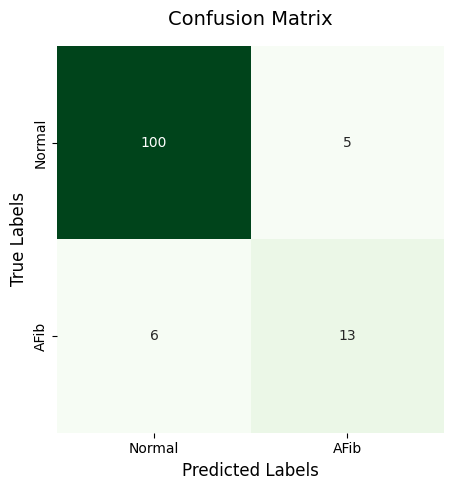

In [19]:
# ===== Plot Confusion Matrix dengan Heatmap =====

def plotHeatMap(y_true, y_pred):
    con_mat = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(con_mat, annot=True, square=True, fmt='g', cmap='Greens', xticklabels=['Normal', 'AFib'], yticklabels=['Normal', 'AFib'], cbar=False)
    plt.title('Confusion Matrix', pad=15, fontsize=14)
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.tight_layout()
    plt.show()
    
plotHeatMap(y_test, prediksi_kelas)

In [20]:
# ===== Evaluasi Model: Accuracy, Precision, Sensitivity, Specificity, F1-Score =====

from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef

y_true = y_test
y_pred = prediksi_kelas

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
accuracy    = accuracy_score(y_true, y_pred)
bal_acc     = balanced_accuracy_score(y_true, y_pred)
precision   = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)

df_metrics = pd.DataFrame({
    'Metrik': ['Accuracy', 'Balanced Accuracy', 'Precision', 'Sensitivity (Recall)', 'Specificity', 'F1-Score', 'MCC (Matthews)'],
    'Persentase': [f'{accuracy*100:.2f}%', f'{bal_acc*100:.2f}%', f'{precision*100:.2f}%', f'{sensitivity*100:.2f}%', f'{specificity*100:.2f}%', f'{f1*100:.2f}%', f'{mcc:.4f}'],
    'Rumus': ['(TP+TN)/(TP+TN+FP+FN)', '(Sens+Spec)/2', 'TP/(TP+FP)', 'TP/(TP+FN)', 'TN/(TN+FP)', '2*(Prec*Rec)/(Prec+Rec)', 'Korelasi Matthews']
})
df_metrics.index = df_metrics.index + 1
display(df_metrics)

df_cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=[0, 1]),
    index=[f'Aktual Normal ({sum(y_true==0)})', f'Aktual AFib ({sum(y_true==1)})'],
    columns=['Prediksi Normal', 'Prediksi AFib']
)
print(f"\nConfusion Matrix (TP={tp}, TN={tn}, FP={fp}, FN={fn}):")
display(df_cm)

,Metrik,Persentase,Rumus
1,Accuracy,91.13%,(TP+TN)/(TP+TN+FP+FN)
2,Balanced Accuracy,81.83%,(Sens+Spec)/2
3,Precision,72.22%,TP/(TP+FP)
4,Sensitivity (Recall),68.42%,TP/(TP+FN)
5,Specificity,95.24%,TN/(TN+FP)
6,F1-Score,70.27%,2*(Prec*Rec)/(Prec+Rec)
7,MCC (Matthews),0.6509,Korelasi Matthews



Confusion Matrix (TP=13, TN=100, FP=5, FN=6):


,Prediksi Normal,Prediksi AFib
Aktual Normal (105),100,5
Aktual AFib (19),6,13


Jumlah window salah prediksi: 11 dari 124


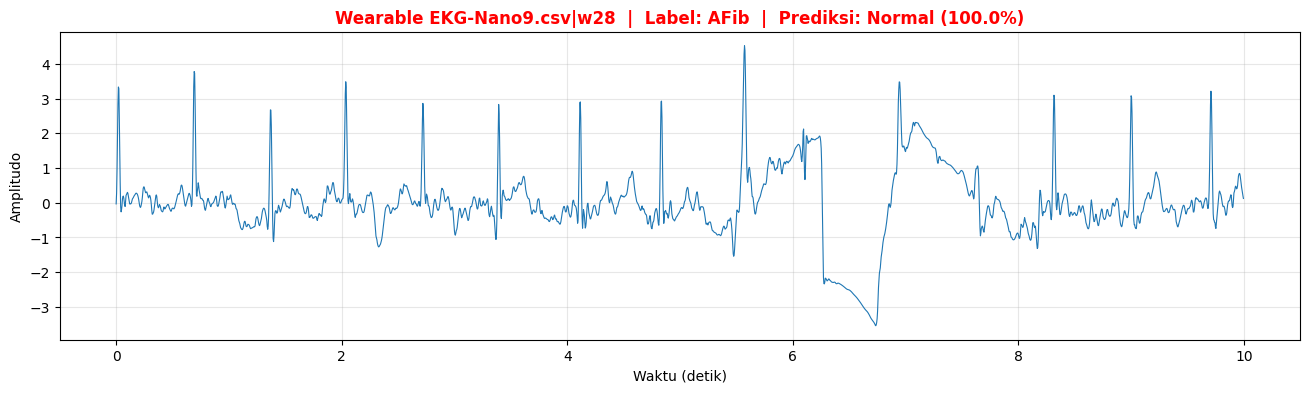

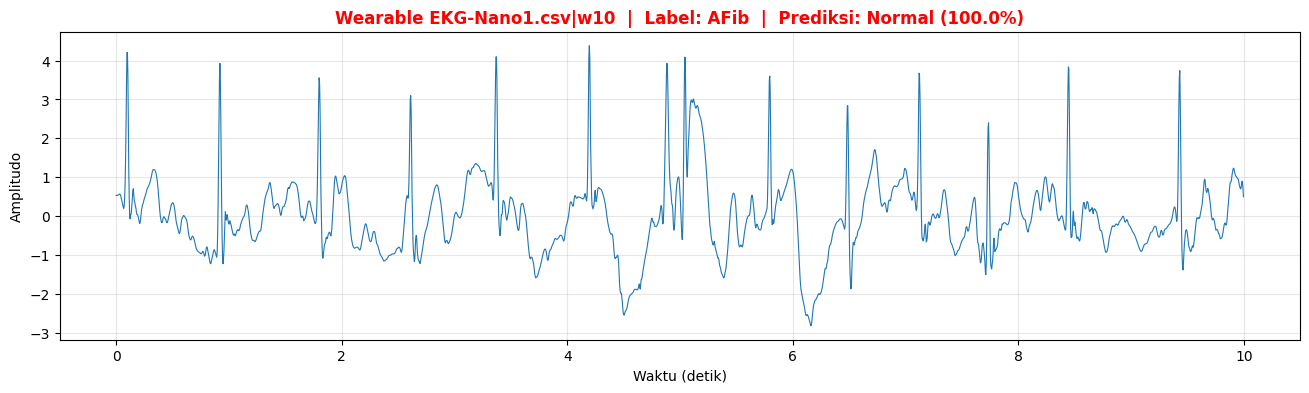

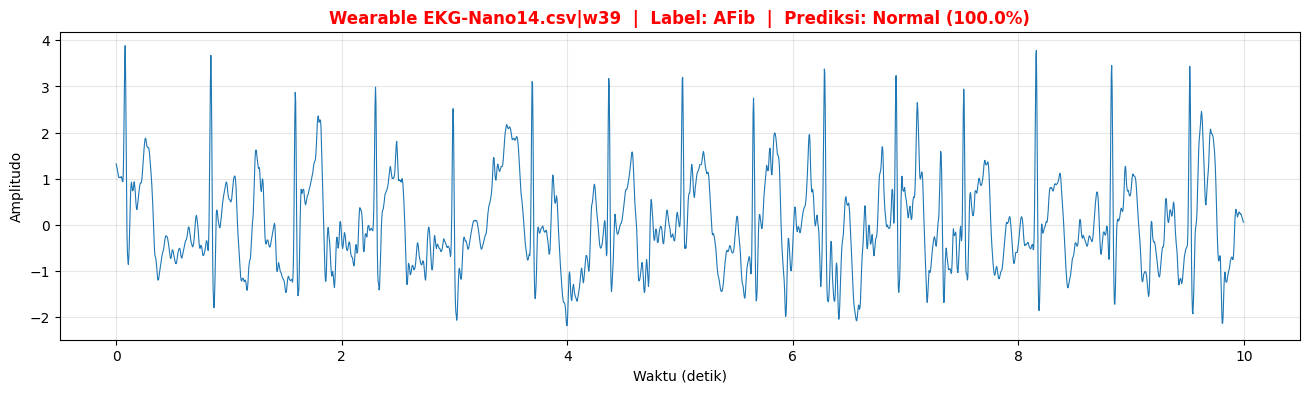

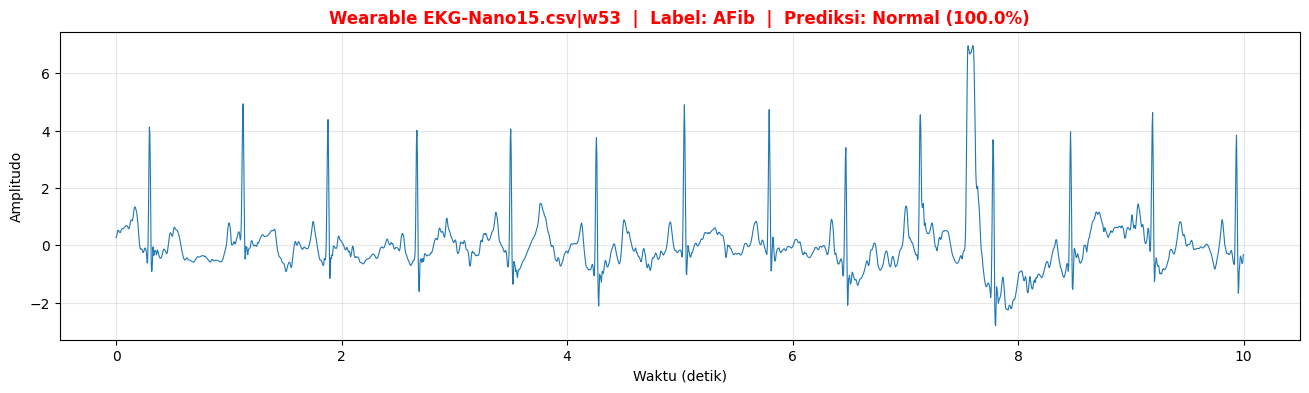

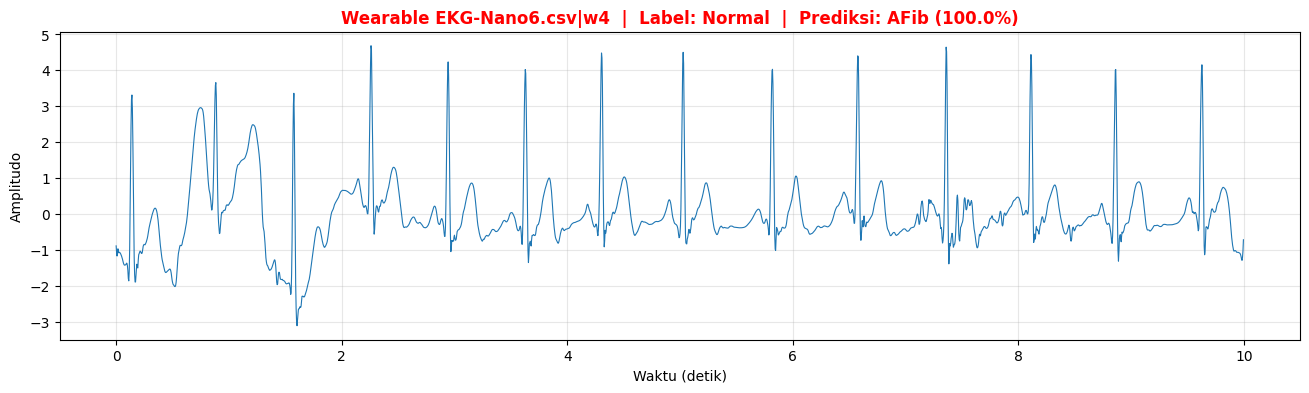

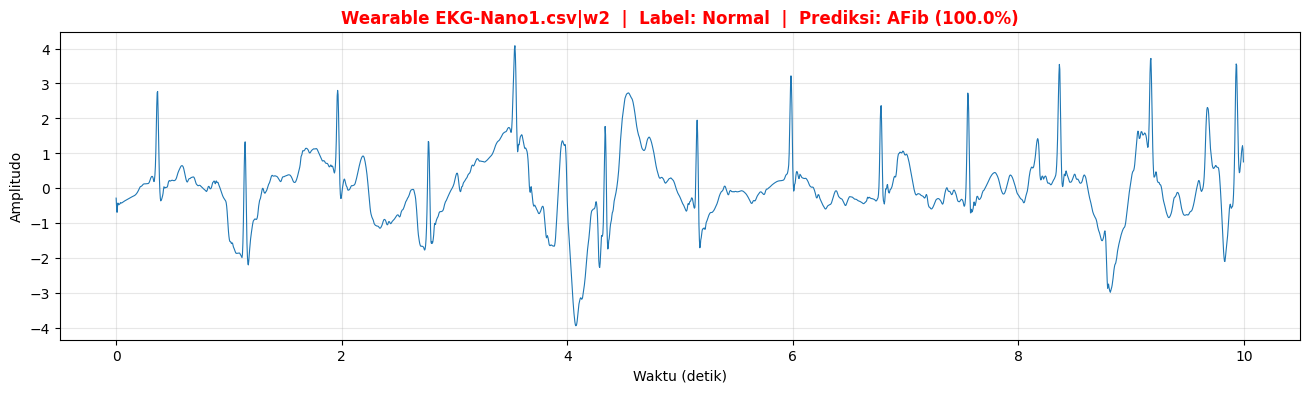

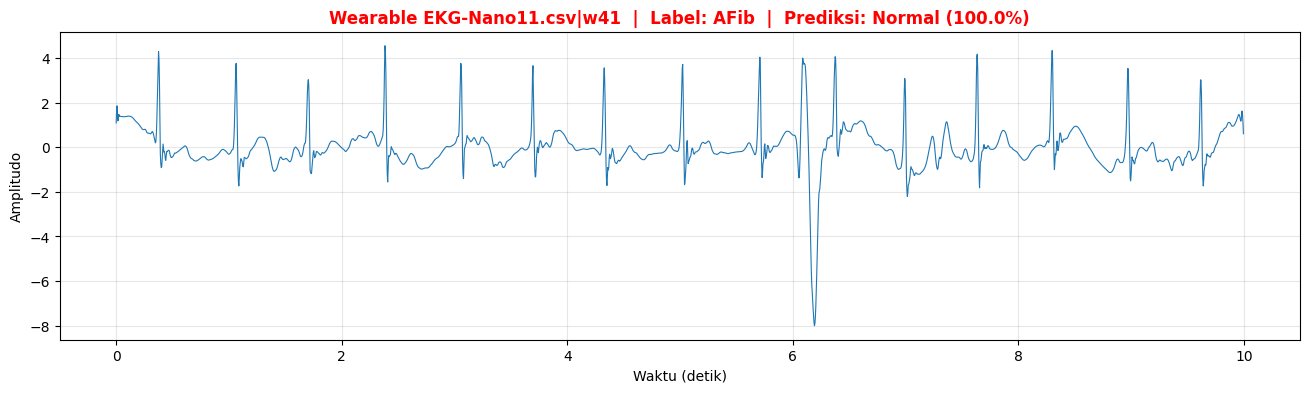

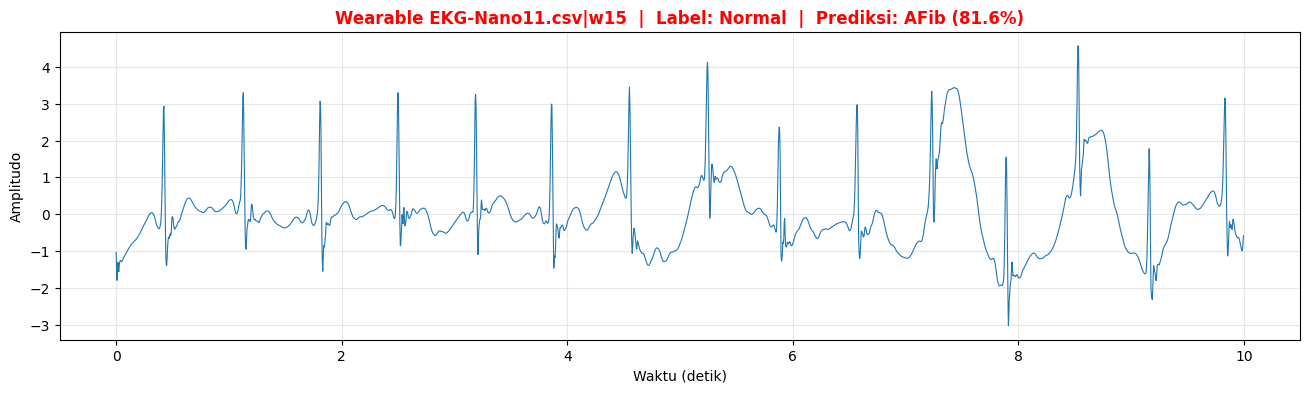

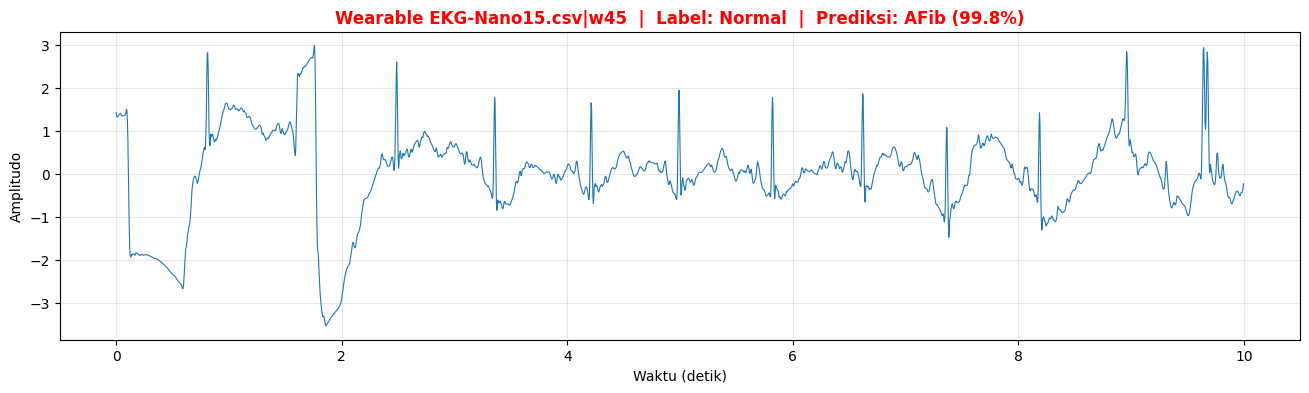

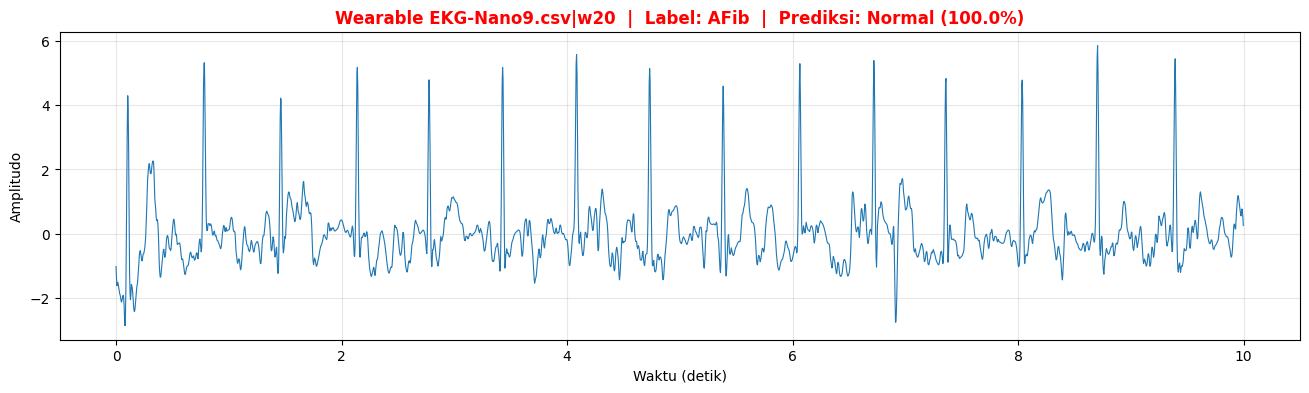

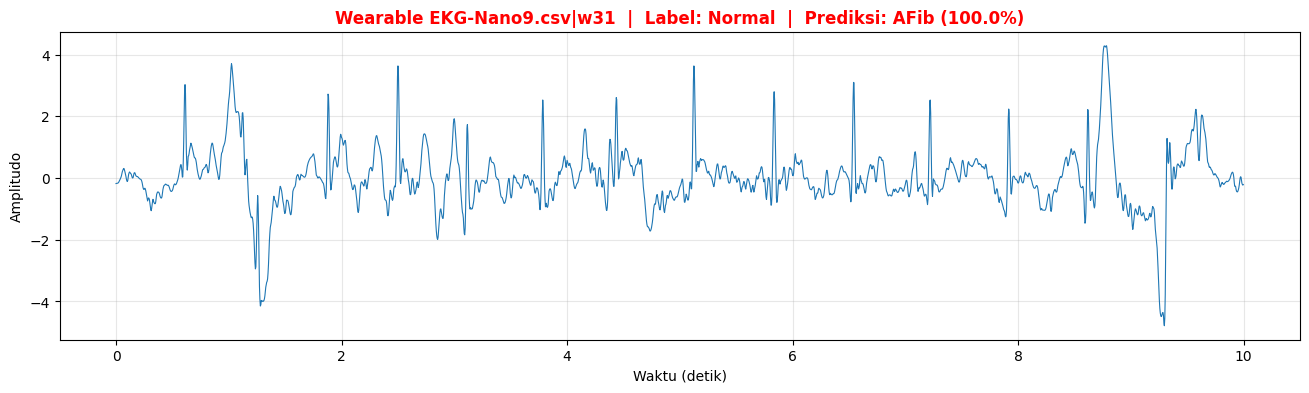

In [21]:
# ===== Cek Visual Window yang Salah Prediksi =====

wrong_indices = [i for i in range(len(y_test)) if y_test[i] != prediksi_kelas[i]]
print(f"Jumlah window salah prediksi: {len(wrong_indices)} dari {len(y_test)}")

for idx in wrong_indices[:20]:
    signal = X_test[idx].squeeze()
    time_axis = np.arange(len(signal)) / 250

    actual = label_map[y_test[idx]]
    pred = label_map[prediksi_kelas[idx]]
    conf = prediksi_prob[idx][prediksi_kelas[idx]] * 100

    plt.figure(figsize=(16, 4))
    plt.plot(time_axis, signal, linewidth=0.8)
    plt.title(f'{wid_test[idx]}  |  Label: {actual}  |  Prediksi: {pred} ({conf:.1f}%)', fontsize=12, fontweight='bold', color='red')
    plt.xlabel('Waktu (detik)')
    plt.ylabel('Amplitudo')
    plt.grid(True, alpha=0.3)
    plt.show()